# 1.3 — Where the liquidity lives

> *"Liquidity is like oxygen: you only notice it when it is gone."* — a saying popular on every trading
> floor after 2008, and on every gas desk after 2022.

## The problem

Chapter 1.2 gave us a fair price for every month three years out. Now try to *trade* month nine. The
screen shows two lots on the bid, three on the offer, and a spread wide enough to park a truck in. The
risk report, meanwhile, wants 300 lots gone by lunchtime.

Three concrete questions:

1. How does tradeable size and cost vary along the curve — months, quarters, seasons, calendars?
2. What does it **cost**, in euros, to execute a hedge of a given size at a given tenor?
3. When the size is too big for the tenor, what are my options?

We have no live order book here, so we work with a **stylised liquidity table** that captures the
well-known qualitative structure. Replace the numbers with your exchange statistics; keep the logic.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.contracts import *
from gashedge.market_data import (synthetic_forward_curve, strip_table, LIQUIDITY_BUCKETS,
                                  HUB_LIQUIDITY_SCALE, FRONT_MONTH_ADV_LOTS, liquidity_for, month_bucket)
from gashedge.hedging import execution_cost
from gashedge.plotting import plot_liquidity
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch1.3")
log.info("Environment ready")

2026-09-13 16:46:52.508 | INFO    | ch1.3 | Environment ready


## 1. The stylised liquidity profile

Three things are robustly true of European gas futures and are encoded in `LIQUIDITY_BUCKETS`:

* **Volume concentrates at the front.** The front month typically trades an order of magnitude more than
  months 7–12, and two orders more than anything beyond a year.
* **Strips are liquid in their own right.** The nearest seasons and the front calendar year are among
  the most traded instruments — hedgers (utilities, producers) think in seasons and years, not months.
* **Hubs differ enormously.** TTF is the benchmark; PEG, THE (Germany) and others trade a small fraction
  of TTF's volume with correspondingly wider spreads.

The table is expressed *relative to the front month*, so you can rescale it with one number
(`FRONT_MONTH_ADV_LOTS`) when you have real data.

In [2]:
liq = LIQUIDITY_BUCKETS.copy()
liq["est_adv_lots_TTF"] = (FRONT_MONTH_ADV_LOTS * liq.rel_adv).round()
liq["est_adv_lots_PEG"] = (FRONT_MONTH_ADV_LOTS * liq.rel_adv * HUB_LIQUIDITY_SCALE["PEG"]).round()
liq["bid_ask_PEG"] = (liq.bid_ask / np.sqrt(HUB_LIQUIDITY_SCALE["PEG"])).round(3)
log.info("Front-month ADV placeholder: %d lots/day; PEG scale %.2f", FRONT_MONTH_ADV_LOTS, HUB_LIQUIDITY_SCALE["PEG"])
liq

2026-09-13 16:46:52.512 | INFO    | ch1.3 | Front-month ADV placeholder: 25000 lots/day; PEG scale 0.06


,rel_adv,bid_ask,depth_lots,est_adv_lots_TTF,est_adv_lots_PEG,bid_ask_PEG
bucket,,,,,,
M1,1.00,0.010,40,25000.0,1500.0,0.041
M2,0.65,0.015,30,16250.0,975.0,0.061
M3,0.35,0.020,20,8750.0,525.0,0.082
M4-M6,0.12,0.035,10,3000.0,180.0,0.143
M7-M12,0.04,0.060,5,1000.0,60.0,0.245
M13+,0.01,0.120,2,250.0,15.0,0.490
Q1-Q2 (nearest quarters),0.30,0.025,15,7500.0,450.0,0.102
Q3+ (further quarters),0.08,0.050,6,2000.0,120.0,0.204
Season (nearest two),0.45,0.020,20,11250.0,675.0,0.082


2026-09-13 16:46:52.520 | INFO    | gashedge.market_data | Synthetic TTF curve as of 2026-09-14: 36 months, front=32.64, level=32.0


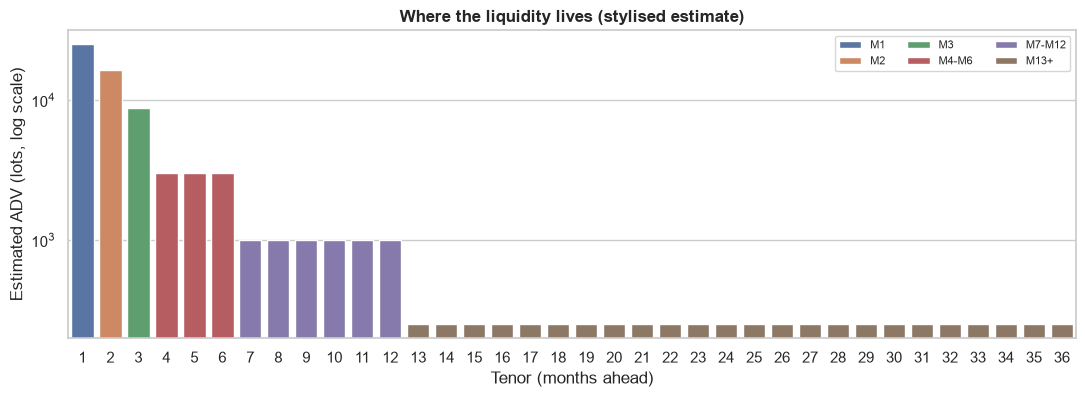

In [3]:
AS_OF = date(2026, 9, 14)
curve = synthetic_forward_curve(AS_OF, n_months=36)
fig, ax = plt.subplots(figsize=(13, 4))
plot_liquidity(curve, ax=ax)
ax.legend(loc="upper right", fontsize=8, ncol=3);

Note the log scale. The drop from tenor 1 to tenor 13+ is two orders of magnitude. Strips partially fill
the gap: a Win-27 strip may trade more than any of its six individual months.

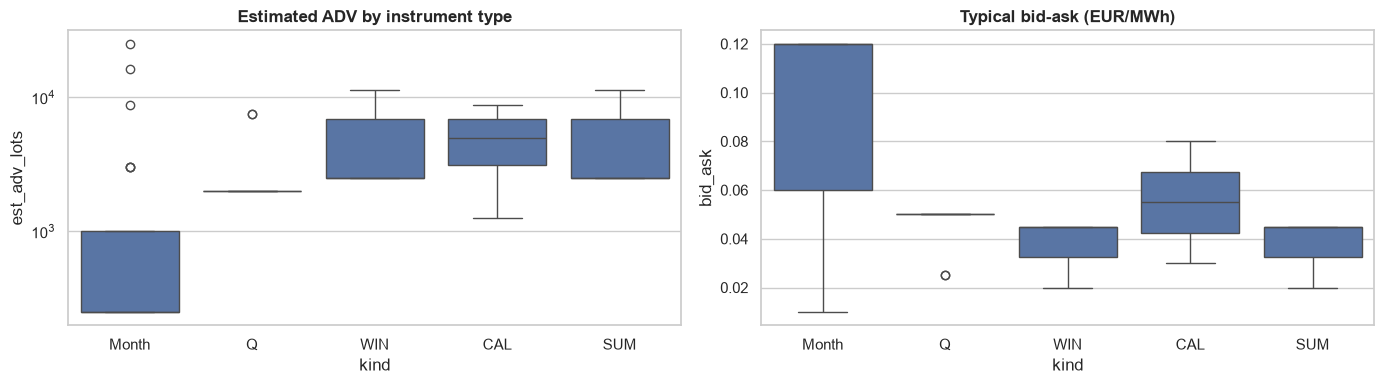

In [4]:
strips = strip_table(curve)
both = pd.concat([
    curve.assign(instrument=curve.symbol, kind="Month")[["instrument", "kind", "est_adv_lots", "bid_ask", "depth_lots"]],
    strips.assign(instrument=strips.strip)[["instrument", "kind", "est_adv_lots", "bid_ask", "depth_lots"]],
])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=both, x="kind", y="est_adv_lots", ax=axes[0]); axes[0].set_yscale("log")
axes[0].set_title("Estimated ADV by instrument type")
sns.boxplot(data=both, x="kind", y="bid_ask", ax=axes[1]); axes[1].set_title("Typical bid-ask (EUR/MWh)")
plt.tight_layout()

## 2. A cost model you can defend

Execution cost has two parts. You always pay **half the bid–ask spread** (you buy at the offer, fair
value is mid). Beyond the size at the touch you **walk the book** — and a very robust empirical finding
across asset classes is that this *market impact* grows with the **square root** of size relative to
available liquidity (the "square-root law"; Almgren et al. 2005, Tóth et al. 2011):

$$
\text{cost}(n) \;=\; n\,H\,\Big[\tfrac{\text{spread}}{2} \;+\; k\,\text{spread}\,\sqrt{n / D}\Big]
\tag{1.8}
$$

where $n$ is lots, $H$ hours per lot, $D$ depth at the touch (lots) and $k \approx 0.5$ a calibration
constant. It is crude and it is *good enough to rank alternatives* — which is all we need it for.

tenor,M1,M15,M3,M6,M9
lots,,,,,
5,25.0,576.0,56.0,111.0,216.0
10,56.0,1445.0,127.0,260.0,521.0
25,167.0,5062.0,394.0,839.0,1747.0
50,394.0,13392.0,960.0,2104.0,4495.0
100,961.0,36029.0,2408.0,5412.0,11820.0
200,2411.0,98208.0,6193.0,14230.0,31642.0
400,6202.0,270378.0,16285.0,38095.0,85919.0


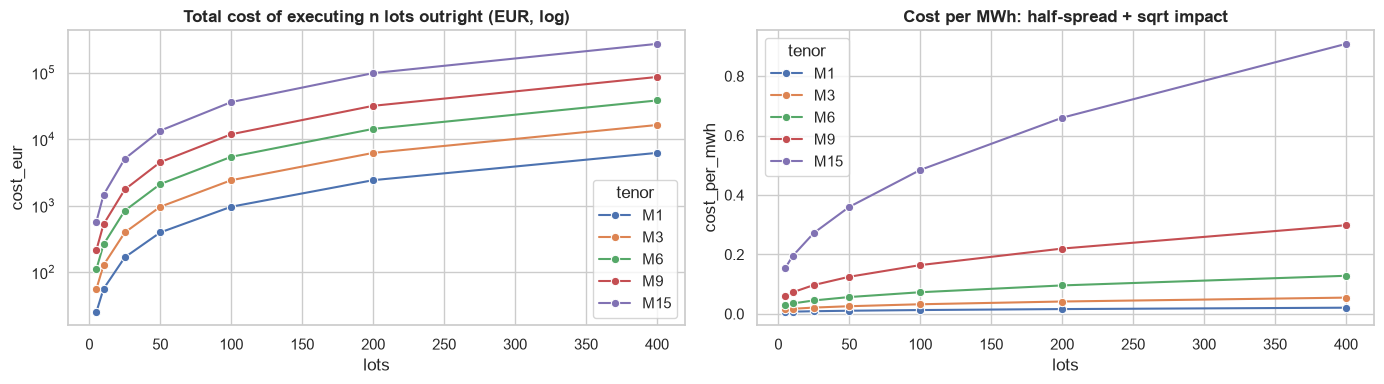

In [5]:
sizes = np.array([5, 10, 25, 50, 100, 200, 400])
rows = []
for tenor in (1, 3, 6, 9, 15):
    row = curve.loc[curve.tenor == tenor].iloc[0]
    for n in sizes:
        c = execution_cost(n, row.bid_ask, row.hours, row.depth_lots)
        rows.append({"tenor": f"M{tenor}", "lots": n, "cost_eur": c, "cost_per_mwh": c / (n * row.hours)})
costs = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=costs, x="lots", y="cost_eur", hue="tenor", marker="o", ax=axes[0]); axes[0].set_yscale("log")
axes[0].set_title("Total cost of executing n lots outright (EUR, log)")
sns.lineplot(data=costs, x="lots", y="cost_per_mwh", hue="tenor", marker="o", ax=axes[1])
axes[1].set_title("Cost per MWh: half-spread + sqrt impact")
plt.tight_layout()
costs.pivot(index="lots", columns="tenor", values="cost_eur").round(0)

Read the right-hand panel carefully: at 100 lots, M1 costs about a cent per MWh; M9 costs more than
**ten times** that. Relative to a €35 price both are small — but hedging is a *repeated* activity, and
a cent a day on a 100-lot book is €270k a year. Execution cost is a first-order design input, not a
footnote.

## 3. Participation limits: size in *days*, not lots

A trader's rule of thumb is that you can absorb roughly 5–15 % of a day's volume without moving the
market against yourself by more than the model suggests. That turns a lot count into a **time to
hedge**:

$$
T_{\text{days}} = \frac{n}{\pi \cdot \text{ADV}}, \qquad \pi \approx 0.10
\tag{1.9}
$$

For the risk manager this is the key liquidity metric: *how many days of market risk do I carry while I
am still executing?* (Chapter 3.4 turns that into a liquidity-adjusted VaR.)

In [6]:
participation = 0.10
need = pd.DataFrame({"instrument": ["TFM M1", "TFM M6", "TFM M9", "TFM M15", "PEG M1", "PEG M6"],
                     "hub": ["TTF"] * 4 + ["PEG"] * 2, "tenor": [1, 6, 9, 15, 1, 6], "lots_to_hedge": [300, 300, 300, 300, 300, 300]})
need["est_adv_lots"] = [liquidity_for(month_bucket(t), h)["est_adv_lots"] for t, h in zip(need.tenor, need.hub)]
need["days_to_execute"] = need.lots_to_hedge / (participation * need.est_adv_lots)
for r in need.itertuples():
    log.info("%-8s 300 lots: ADV %6.0f -> %.1f trading days at %.0f%% participation", r.instrument, r.est_adv_lots,
             r.days_to_execute, 100 * participation)
need

2026-09-13 16:46:53.212 | INFO    | ch1.3 | TFM M1   300 lots: ADV  25000 -> 0.1 trading days at 10% participation


2026-09-13 16:46:53.213 | INFO    | ch1.3 | TFM M6   300 lots: ADV   3000 -> 1.0 trading days at 10% participation


2026-09-13 16:46:53.214 | INFO    | ch1.3 | TFM M9   300 lots: ADV   1000 -> 3.0 trading days at 10% participation


2026-09-13 16:46:53.214 | INFO    | ch1.3 | TFM M15  300 lots: ADV    250 -> 12.0 trading days at 10% participation


2026-09-13 16:46:53.215 | INFO    | ch1.3 | PEG M1   300 lots: ADV   1500 -> 2.0 trading days at 10% participation


2026-09-13 16:46:53.215 | INFO    | ch1.3 | PEG M6   300 lots: ADV    180 -> 16.7 trading days at 10% participation


,instrument,hub,tenor,lots_to_hedge,est_adv_lots,days_to_execute
0,TFM M1,TTF,1,300,25000.0,0.120000
1,TFM M6,TTF,6,300,3000.0,1.000000
2,TFM M9,TTF,9,300,1000.0,3.000000
3,TFM M15,TTF,15,300,250.0,12.000000
4,PEG M1,PEG,1,300,1500.0,2.000000
5,PEG M6,PEG,6,300,180.0,16.666667


Three hundred lots of PEG month six is not "a trade"; it is a **campaign** lasting weeks, during which
the position is unhedged. Which leads to the central idea of Module 2: *hedge the liquid proxy now,
migrate to the precise instrument later — if ever.*

## 4. The curve is traded in spreads

A fact that surprises newcomers: the back of the curve is often *more* liquid than it looks, because
professionals trade **calendar spreads** (M1/M2, Q1/Q2, Win/Sum) as instruments in their own right, and
the exchange lists them with implied pricing. To take a position in M6 you can trade the liquid M1 and
the M1/M6 spread. The spread's bid–ask is typically *tighter* than the outright M6 because a spread
market-maker carries far less risk (the two legs are highly correlated — Chapter 1.4).

The cost comparison below is stylised but the mechanism is real.

In [7]:
m1, m6 = curve.loc[curve.tenor == 1].iloc[0], curve.loc[curve.tenor == 6].iloc[0]
n = 100
spread_bid_ask, spread_depth = 0.020, 20          # stylised: M1/M6 spread quoted tighter than M6 outright
outright = execution_cost(n, m6.bid_ask, m6.hours, m6.depth_lots)
via_spread = execution_cost(n, m1.bid_ask, m1.hours, m1.depth_lots) + execution_cost(n, spread_bid_ask, m6.hours, spread_depth)
log.info("100 lots into M6: outright %.0f EUR vs M1 + M1/M6 spread %.0f EUR (saving %.0f%%)", outright, via_spread,
         100 * (1 - via_spread / outright))
pd.Series({"M6 outright": outright, "M1 leg + M1/M6 spread": via_spread}, name="cost_eur").round(0)

2026-09-13 16:46:53.229 | INFO    | ch1.3 | 100 lots into M6: outright 5412 EUR vs M1 + M1/M6 spread 3366 EUR (saving 38%)


M6 outright              5412.0
M1 leg + M1/M6 spread    3366.0
Name: cost_eur, dtype: float64

## 5. Hubs: the same curve, a tenth of the liquidity

Everything above gets *harder* on PEG. Volumes are a fraction of TTF, spreads are wider, depth is
thinner. But PEG and TTF prices move almost together (Chapter 1.5) — which means that the *cheapest*
place to lay off PEG risk is very often TTF, accepting a small **basis risk** in exchange for a large
saving in execution cost and time. Whether that trade-off is worth it is precisely what Module 3
quantifies.

## 6. Where this leaves us

We now know that the instruments we would *like* to trade (exact month, exact hub) are frequently not
the ones we *can* trade in size. A hedging engine must therefore map every exposure to a liquid proxy
and be explicit about what is left over.

**Pitfall that leads to the next chapter:** we have implicitly treated 1 MWh in M1 and 1 MWh in M12 as
interchangeable risk. They are not: the front of the curve moves two to three times more than the back,
and not in lock-step. Before we hedge M12 with M1 we must understand *how the curve moves* — Chapter 1.4.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Using equation (1.8) with $k=0.5$: what is the cost of buying 100 lots of a 744-hour month when the bid–ask is 0.06 EUR/MWh and depth is 5 lots? Compare with 100 lots of M1 (bid–ask 0.01, depth 40).

<details><summary><i>Answer 1</i></summary>

Back month: per-MWh cost $= 0.03 + 0.5 \times 0.06 \times \sqrt{100/5} = 0.03 + 0.03\sqrt{20} = 0.03 + 0.1342 = 0.1642$ EUR/MWh; total $= 100 \times 744 \times 0.1642 \approx \mathbf{€12{,}200}$. Front month: $0.005 + 0.5\times0.01\times\sqrt{2.5} = 0.005 + 0.0079 = 0.0129$ EUR/MWh; total $\approx \mathbf{€960}$. Roughly a **13×** difference — and the impact term dominates for the back month (0.134 of 0.164), so splitting the order over several days would help far more at the back than at the front.

</details>

**Q2.** You must hedge 2,000 lots in an instrument with ADV 3,000 lots. At 10 % participation how many trading days does it take, and what two things are you exposed to during that time?

<details><summary><i>Answer 2</i></summary>

$T = 2000 / (0.10 \times 3000) = 6.7 \to$ **about 7 trading days**. During execution you carry (i) *outright market risk* on the unexecuted remainder (declining linearly if you execute evenly), and (ii) *information leakage / adverse selection*: a persistent one-sided flow lets others infer your intent and move prices against you. Both argue for hedging the liquid proxy immediately and working the precise instrument over time.

</details>

**Q3.** Why can a calendar spread (say M1/M6) be quoted with a tighter bid–ask than the M6 outright, even though it involves two contracts?

<details><summary><i>Answer 3</i></summary>

The market-maker's inventory risk on a spread is the *spread* volatility, not the outright volatility. Because M1 and M6 are highly correlated (ρ ≈ 0.8–0.95), $\sigma_{\text{spread}}^2 = \sigma_1^2 + \sigma_6^2 - 2\rho\sigma_1\sigma_6$ is much smaller than $\sigma_6^2$. Less risk per unit inventory → narrower quote. Spreads also attract natural two-way flow (storage players, roll activity), which further compresses the quote.

</details>

**Q4.** A PEG desk asks you to hedge 150 lots of PEG M6 today. Sketch two execution plans and state the risk you retain in each.

<details><summary><i>Answer 4</i></summary>

**Plan A (precise, slow):** work PEG M6 directly at ≤10 % participation. With stylised PEG M6 ADV of ~180 lots this takes ~8 days; you retain full outright PEG risk on the unfilled remainder for over a week. **Plan B (proxy, fast):** sell ~150 lots of TTF M1 (or M6 via M1 + spread) within minutes, then optionally migrate to PEG over time. You retain (i) *basis risk* PEG–TTF (Chapter 1.5), (ii) *tenor risk* if you used M1 (Chapter 1.4), and nothing else. Most desks choose B and manage the residuals statistically — Module 3.

</details>


---
◀ [Previous](02_curve_and_strips.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](04_curve_dynamics.ipynb)